In [329]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import scipy.io as sio
import math
import matplotlib.pyplot as plt

In [330]:
# 导入数据
file_path = r"D:\红茶数据2024.0423\300\dataAfterSNV\sugar.mat"
data = sio.loadmat(file_path)
# 提取X和Y
X = data['X']
Y = data['Y'] 

In [331]:
# 使用 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [332]:
# K折交叉验证
kf = KFold(n_splits=4, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # 数据归一化
    scaler_X = MinMaxScaler()
    scaler_Y = MinMaxScaler()

    X_train = scaler_X.fit_transform(X_train)
    X_test = scaler_X.transform(X_test)

    Y_train = scaler_Y.fit_transform(Y_train.reshape(-1, 1))
    Y_test = scaler_Y.transform(Y_test.reshape(-1, 1))

    # 转换为 PyTorch 张量
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1).unsqueeze(3)  
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).unsqueeze(3)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

    # 在这里添加模型训练和评估的代码

In [333]:
    # 打印训练集和测试集的张量形状
print(f"Training set size: {X_train_tensor.shape}")
print(f"Test set size: {X_test_tensor.shape}")

Training set size: torch.Size([225, 1, 167, 1])
Test set size: torch.Size([75, 1, 167, 1])


In [334]:
# Squeeze-and-Excitation Block
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction, bias=False)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        y = torch.mean(x, dim=(2, 3), keepdim=False)  # Global Average Pooling
        y = self.fc1(y)
        y = F.relu(y)
        y = self.fc2(y)
        y = self.sigmoid(y).view(b, c, 1, 1)
        return x * y  # Apply SE weights to the input


# Basic Block with SE
class SEBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, reduction=16):
        super(SEBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels, reduction)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.se(out)

        out += identity
        out = self.relu(out)

        return out

# Squeeze-and-Excitation Block
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16, dropout_rate=0.1):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction, bias=False)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels, bias=False)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_rate)  # 添加Dropout

    def forward(self, x):
        b, c, _, _ = x.size()
        y = torch.mean(x, dim=(2, 3), keepdim=False)  # Global Average Pooling
        y = self.fc1(y)
        y = F.relu(y)
        y = self.dropout(y)  # 在第一个FC层后应用Dropout
        y = self.fc2(y)
        y = self.sigmoid(y).view(b, c, 1, 1)
        return x * y  # Apply SE weights to the input


# Basic Block with SE
class SEBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, reduction=16, dropout_rate=0.1):
        super(SEBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels, reduction, dropout_rate)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout_rate)  # 添加2D Dropout
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.dropout(out)  # 第一个卷积层后应用Dropout
        
        out = self.conv2(out)
        out = self.bn2(out)

        out = self.se(out)

        out += identity
        out = self.relu(out)

        return out


# SE-ResNet-18 for Regression
class SEResNet18_Regressor(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(SEResNet18_Regressor, self).__init__()
        self.in_channels = 64
        self.dropout_rate = dropout_rate
        
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(4, 1), stride=(2, 1), padding=(3, 0), bias=False)  # 1-channel input
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        self.dropout = nn.Dropout(dropout_rate)  # 添加Dropout

        # ResNet layers with SE blocks
        self.layer1 = self._make_layer(SEBasicBlock, 64, 2)
        self.layer2 = self._make_layer(SEBasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(SEBasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(SEBasicBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout_fc = nn.Dropout(dropout_rate * 1.5)  # 在全连接层前使用较高的Dropout率
        self.fc = nn.Linear(512, 1)  # Output 1 value for regression

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample, dropout_rate=self.dropout_rate))
        self.in_channels = out_channels  # Update in_channels for subsequent layers

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, dropout_rate=self.dropout_rate))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.dropout(x)  # 在初始特征提取后应用Dropout

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x) 
        x = torch.flatten(x, 1)
        x = self.dropout_fc(x)  # 在全连接层之前应用更高比例的Dropout
        x = self.fc(x)
        return x



In [335]:
#模型训练
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # 自动选择GPU（如果可用
# 将输入数据移到 GPU
X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
Y_train_tensor = Y_train_tensor.to(device)
Y_test_tensor = Y_test_tensor.to(device)

# 将目标张量展平，确保与模型输出的形状一致
Y_train_tensor = Y_train_tensor.flatten()
Y_test_tensor = Y_test_tensor.flatten()
# 初始化模型
model = SEResNet18_Regressor().to(device)

# 损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.0001)  # 学习率调度器, 每500个epoch将学习率减小为原来的0.1

# 训练模型
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    
    # 前向传播
    outputs = model(X_train_tensor)
    loss = criterion(outputs.flatten(), Y_train_tensor)
    
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    # 打印日志
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

# 测试模型
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions.flatten(), Y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')


Epoch [100/1000], Loss: 0.0377, LR: 0.000000
Epoch [200/1000], Loss: 0.0403, LR: 0.000000
Epoch [300/1000], Loss: 0.0422, LR: 0.000000
Epoch [400/1000], Loss: 0.0400, LR: 0.000000
Epoch [500/1000], Loss: 0.0424, LR: 0.000000
Epoch [600/1000], Loss: 0.0374, LR: 0.000000
Epoch [700/1000], Loss: 0.0395, LR: 0.000000
Epoch [800/1000], Loss: 0.0416, LR: 0.000000
Epoch [900/1000], Loss: 0.0376, LR: 0.000000
Epoch [1000/1000], Loss: 0.0378, LR: 0.000000
Test Loss: 0.0364


In [336]:
# 定义保存路径
model_save_path = "trained_seresnet18.pth"

# 保存模型参数
torch.save(model.state_dict(), model_save_path)
print(f"模型参数已保存到 {model_save_path}")


模型参数已保存到 trained_seresnet18.pth


In [337]:
# 模型预测
model.eval()
with torch.no_grad():
    Y_train_pred = model(X_train_tensor).flatten()
    Y_test_pred = model(X_test_tensor).flatten()

Train Rc: 0.8922
Test Rp: 0.6856
Train RMSE: 0.5190
Test RMSE: 0.8048
训练集数据的 RPD 为：2.2144
测试集数据的 RPD 为：1.3736


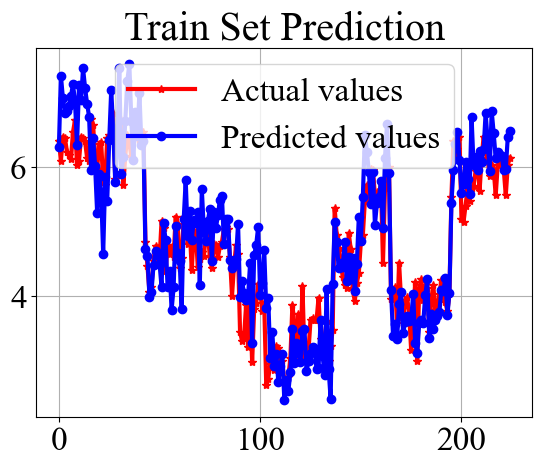

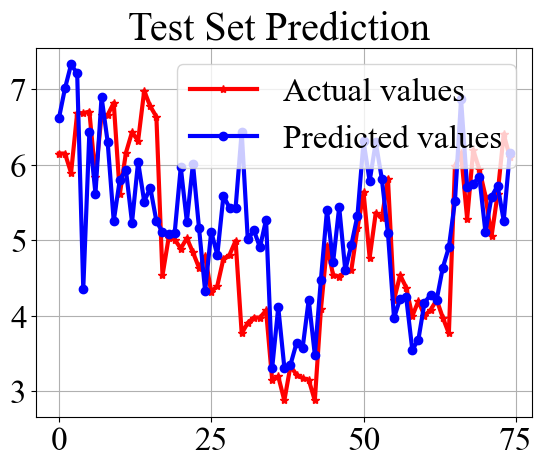

In [338]:
#画图及计算指标
import matplotlib.pyplot as plt

# 设置字体为支持中文的字体
plt.rcParams['font.family'] = 'times new roman'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# Data inverse normalization
Y_train_pred = scaler_Y.inverse_transform(Y_train_pred.cpu().numpy().reshape(-1, 1)).flatten()
Y_test_pred = scaler_Y.inverse_transform(Y_test_pred.cpu().numpy().reshape(-1, 1)).flatten()
Y_train_actual = scaler_Y.inverse_transform(Y_train_tensor.cpu().numpy().reshape(-1, 1)).flatten()
Y_test_actual = scaler_Y.inverse_transform(Y_test_tensor.cpu().numpy().reshape(-1, 1)).flatten()


# Root Mean Squared Error (RMSE)
train_rmse = np.sqrt(mean_squared_error(Y_train_actual, Y_train_pred))
test_rmse = np.sqrt(mean_squared_error(Y_test_actual, Y_test_pred))
# R² coefficient calculation
train_r2 = 1 - np.sum((Y_train_actual - Y_train_pred) ** 2) / np.sum((Y_train_actual - np.mean(Y_train_actual)) ** 2)
test_r2 = 1 - np.sum((Y_test_actual - Y_test_pred) ** 2) / np.sum((Y_test_actual - np.mean(Y_test_actual)) ** 2)

Rc = math.sqrt(train_r2)
print(f'Train Rc: {Rc:.4f}')
Rp = math.sqrt(test_r2)
print(f'Test Rp: {Rp:.4f}')

print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')

# 计算基准数据（实际观测数据）的标准差
sd_reference_train = np.std(Y_train_actual)
sd_reference_test = np.std(Y_test_actual)

# 计算 RPD
rpd_train = sd_reference_train / train_rmse  # 使用训练集的 RMSE
rpd_test = sd_reference_test / test_rmse    # 使用测试集的 RMSE

# 显示结果
print(f'训练集数据的 RPD 为：{rpd_train:.4f}')
print(f'测试集数据的 RPD 为：{rpd_test:.4f}')
# Plotting the prediction results
plt.figure()
plt.plot(Y_train_actual, 'r-*', label='Actual values')
plt.plot(Y_train_pred, 'b-o', label='Predicted values')
plt.title(f'Train Set Prediction')
plt.legend()
plt.grid()

plt.figure()
plt.plot(Y_test_actual, 'r-*', label='Actual values')
plt.plot(Y_test_pred, 'b-o', label='Predicted values')
plt.title(f'Test Set Prediction ')
plt.legend()
plt.grid()

plt.show()


# MAE and MBE calculation
#train_mae = mean_absolute_error(Y_train_actual, Y_train_pred)
#test_mae = mean_absolute_error(Y_test_actual, Y_test_pred)

#train_mbe = np.mean(Y_train_pred - Y_train_actual)
#test_mbe = np.mean(Y_test_pred - Y_test_actual)

#print(f'Train MAE: {train_mae:.4f}')
#print(f'Test MAE: {test_mae:.4f}')
#print(f'Train MBE: {train_mbe:.4f}')
#print(f'Test MBE: {test_mbe:.4f}')


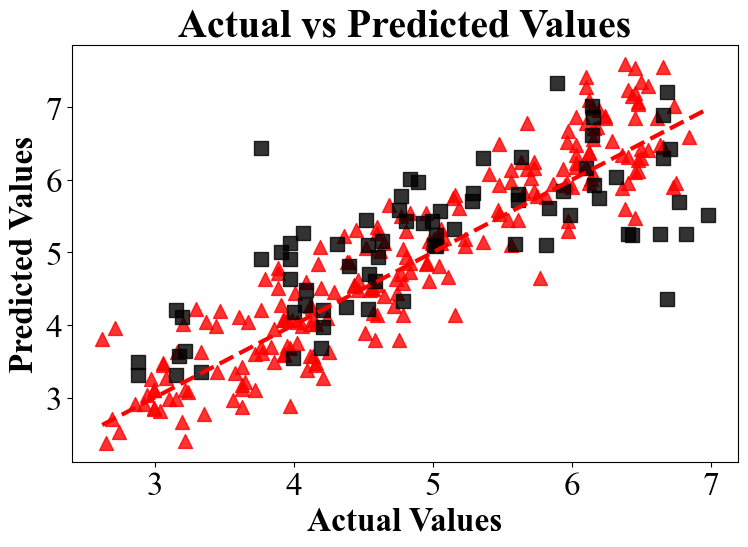

In [339]:
import matplotlib.pyplot as plt

# 调整字体
plt.rcParams['font.size'] = 24
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['lines.linewidth'] = 3

# 创建图像
plt.figure(figsize=(8, 6))

# 绘制 Train set（红色三角）
plt.scatter(Y_train_actual, Y_train_pred, c='red', marker='^', label='Train set', alpha=0.8, s=100)

# 绘制 Test set（黑色方块）
plt.scatter(Y_test_actual, Y_test_pred, c='black', marker='s', label='Test set', alpha=0.8, s=100)

# 绘制 y=x 参考线
max_val = max(Y_train_actual.max(), Y_test_actual.max())
min_val = min(Y_train_actual.min(), Y_test_actual.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal fit (y=x)')

# 设置标题和标签
plt.title('Actual vs Predicted Values', fontweight='bold')
plt.xlabel('Actual Values', fontweight='bold')
plt.ylabel('Predicted Values', fontweight='bold')

# 图例与网格

plt.tight_layout() #显示
plt.show()


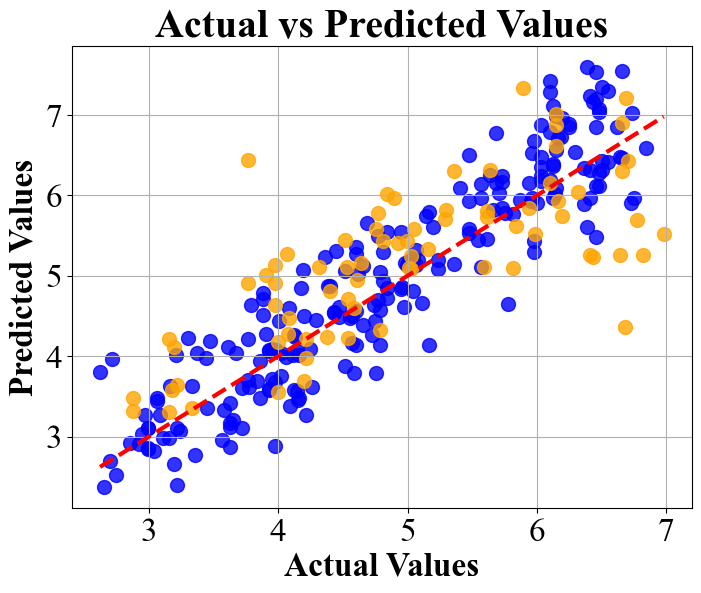

In [340]:
import matplotlib.pyplot as plt
# 调整字体
plt.rcParams['font.size'] = 24  # 设置全局字体大小
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 生成散点图比较真实值和预测值
plt.figure(figsize=(8, 6)) #尺寸  
plt.rcParams['lines.linewidth'] = 3  # 设置全局线宽
# 绘制训练集散点图
plt.scatter(Y_train_actual, Y_train_pred, c='blue', label='Train set', alpha=0.8, s=100)
plt.scatter(Y_test_actual, Y_test_pred, c='orange', label='Test set', alpha=0.8, s=100)

# 绘制 y=x 参考线
max_val = max(Y_train_actual.max(), Y_test_actual.max())
min_val = min(Y_train_actual.min(), Y_test_actual.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal fit (y=x)')

# 设置图形标题和标签
plt.title('Actual vs Predicted Values', fontweight='bold')
plt.xlabel('Actual Values', fontweight='bold')
plt.ylabel('Predicted Values', fontweight='bold')

plt.grid()
plt.show()
